# **TCC - PERFIS DE DESEMPENHO NO ENEM(2018–2023) EM MUNICÍPIOS DA ÁREA DE ABRANGÊNCIA DO IFNMG**

Nesta terceira etapa, daremos continuidade à análise avançando para a aplicação de métodos de agrupamento (clustering). O objetivo será identificar padrões e perfis entre os candidatos do ENEM a partir das variáveis selecionadas, considerando tanto aspectos socioeconômicos quanto de desempenho. Para isso, partiremos da base já limpa e padronizada, aplicaremos técnicas de normalização quando necessário e utilizaremos algoritmos de agrupamento, como o k-means, de forma a organizar os candidatos em grupos com características semelhantes. Em seguida, avaliaremos a qualidade desses agrupamentos por meio de métricas como o coeficiente de silhueta, permitindo interpretar os resultados e destacar perfis relevantes que auxiliem na compreensão do contexto educacional da região de abrangência do IFNMG.

Importando as bibliotecas que serão utilizadas.

In [2]:
import os
import re
import pandas as pd
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from matplotlib.ticker import FuncFormatter
from kmodes.kmodes import KModes

### **Realizando a leitura da base de área de MG**

In [3]:
df_final = pd.read_parquet(r"C:\Users\fernanda.leal\Documents\FERNANDA\TCC\DESENVOLVIMENTO\BASES\processed\MG.parquet", engine="fastparquet")
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,M,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,F,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
2,2018,11,M,0.0,3,1,2,2,3.0,Boa Esperança,...,B,A,A,A,A,A,B,B,B,B
3,2018,12,F,0.0,3,1,2,2,3.0,Vespasiano,...,A,A,A,B,A,A,B,A,A,A
4,2018,2,M,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,M,1.0,2,3,2,2,NaN,Rio Vermelho,...,A,A,A,A,A,A,C,A,A,B
517823,2023,2,F,1.0,1,1,2,2,1.0,Juiz de Fora,...,A,A,A,C,A,A,D,A,A,B
517824,2023,2,M,1.0,1,1,2,2,1.0,Pouso Alegre,...,A,A,B,B,A,B,E,A,D,B
517825,2023,2,F,1.0,3,1,2,2,1.0,Ipaba,...,B,A,A,B,A,A,D,A,B,B


### **Codificação das variáveis**
Nesse caso, será realizado a transformação da variável **TP_SEXO**, convertendo o valor 'M' para 0 e o valor 'F' para 1.

In [4]:
df_final["TP_SEXO"] = df_final["TP_SEXO"].map({"F": 1, "M": 0})
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,0,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,1,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
2,2018,11,0,0.0,3,1,2,2,3.0,Boa Esperança,...,B,A,A,A,A,A,B,B,B,B
3,2018,12,1,0.0,3,1,2,2,3.0,Vespasiano,...,A,A,A,B,A,A,B,A,A,A
4,2018,2,0,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,2,3,2,2,NaN,Rio Vermelho,...,A,A,A,A,A,A,C,A,A,B
517823,2023,2,1,1.0,1,1,2,2,1.0,Juiz de Fora,...,A,A,A,C,A,A,D,A,A,B
517824,2023,2,0,1.0,1,1,2,2,1.0,Pouso Alegre,...,A,A,B,B,A,B,E,A,D,B
517825,2023,2,1,1.0,3,1,2,2,1.0,Ipaba,...,B,A,A,B,A,A,D,A,B,B


Nesse caso, a variável **TP_ESTADO_CIVIL** foi recodificada para valores numéricos, de forma que Solteiro(a) foi representado por 0, Casado(a)/Companheiro(a) por 1, e as demais categorias (Divorciado(a), Desquitado(a), Separado(a) e Viúvo(a)) foram agrupadas sob o valor 2, representando o grupo “Outros”

In [5]:
df_final["TP_ESTADO_CIVIL"] = df_final["TP_ESTADO_CIVIL"].replace({
    "Solteiro(a)": 0,
    "Casado(a)/Companheiro(a)": 1,
    "Divorciado(a)/Separado(a)": 2,
    "Desquitado(a)": 2,
    "Viúvo(a)": 2
})
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,0,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,1,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
2,2018,11,0,0.0,3,1,2,2,3.0,Boa Esperança,...,B,A,A,A,A,A,B,B,B,B
3,2018,12,1,0.0,3,1,2,2,3.0,Vespasiano,...,A,A,A,B,A,A,B,A,A,A
4,2018,2,0,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,2,3,2,2,NaN,Rio Vermelho,...,A,A,A,A,A,A,C,A,A,B
517823,2023,2,1,1.0,1,1,2,2,1.0,Juiz de Fora,...,A,A,A,C,A,A,D,A,A,B
517824,2023,2,0,1.0,1,1,2,2,1.0,Pouso Alegre,...,A,A,B,B,A,B,E,A,D,B
517825,2023,2,1,1.0,3,1,2,2,1.0,Ipaba,...,B,A,A,B,A,A,D,A,B,B


Nesse caso, aplicou-se o método one-hot encoding à variável **TP_COR_RACA**, criando colunas binárias (0 e 1) para cada categoria de cor/raça. Essa transformação permite representar variáveis categóricas de forma numérica, sem atribuir uma ordem entre as categorias.

In [6]:
df_final = pd.get_dummies(df_final, columns=["TP_COR_RACA"], prefix="COR_RACA")
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,1,2,2,1.0,Rio Pardo de Minas,MG,...,D,A,A,A,True,False,False,False,False,False
1,2018,2,1,0.0,1,2,2,1.0,São Francisco,MG,...,D,A,A,B,False,False,False,True,False,False
2,2018,11,0,0.0,1,2,2,3.0,Boa Esperança,MG,...,B,B,B,B,False,False,False,True,False,False
3,2018,12,1,0.0,1,2,2,3.0,Vespasiano,MG,...,B,A,A,A,False,False,False,True,False,False
4,2018,2,0,0.0,1,2,2,1.0,Montalvânia,MG,...,C,A,B,B,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,3,2,2,NaN,Rio Vermelho,MG,...,C,A,A,B,False,False,True,False,False,False
517823,2023,2,1,1.0,1,2,2,1.0,Juiz de Fora,MG,...,D,A,A,B,False,True,False,False,False,False
517824,2023,2,0,1.0,1,2,2,1.0,Pouso Alegre,MG,...,E,A,D,B,False,True,False,False,False,False
517825,2023,2,1,1.0,1,2,2,1.0,Ipaba,MG,...,D,A,B,B,False,False,False,True,False,False


Nesta etapa, será realizada a recodificação da variável **TP_NACIONALIDADE**, transformando as categorias originais em valores numéricos binários:

0 → Brasileiro(a), Brasileiro(a) Naturalizado(a) ou Brasileiro(a) Nato(a), nascido(a) no exterior

1 → Estrangeiro(a)

As observações com valor 0 (Não informado) serão removidas do conjunto de dados.

In [7]:
antes = len(df_final)
print(f"Total de linhas antes da exclusão: {antes}")

df_final = df_final[df_final["TP_NACIONALIDADE"] != 0].copy()

df_final.loc[:, "TP_NACIONALIDADE"] = df_final["TP_NACIONALIDADE"].replace({
    1: 0,  # Brasileiro(a)
    2: 0,  # Brasileiro(a) Naturalizado(a)
    4: 0,  # Brasileiro(a) Nato(a), nascido(a) no exterior
    3: 1   # Estrangeiro(a)
})

depois = len(df_final)
print(f"Total de linhas após a exclusão: {depois}")
print(f"Foram removidas {antes - depois} linhas (Não informadas).")
df_final

Total de linhas antes da exclusão: 517827
Total de linhas após a exclusão: 517522
Foram removidas 305 linhas (Não informadas).


,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,0,2,2,1.0,Rio Pardo de Minas,MG,...,D,A,A,A,True,False,False,False,False,False
1,2018,2,1,0.0,0,2,2,1.0,São Francisco,MG,...,D,A,A,B,False,False,False,True,False,False
2,2018,11,0,0.0,0,2,2,3.0,Boa Esperança,MG,...,B,B,B,B,False,False,False,True,False,False
3,2018,12,1,0.0,0,2,2,3.0,Vespasiano,MG,...,B,A,A,A,False,False,False,True,False,False
4,2018,2,0,0.0,0,2,2,1.0,Montalvânia,MG,...,C,A,B,B,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,1,2,2,NaN,Rio Vermelho,MG,...,C,A,A,B,False,False,True,False,False,False
517823,2023,2,1,1.0,0,2,2,1.0,Juiz de Fora,MG,...,D,A,A,B,False,True,False,False,False,False
517824,2023,2,0,1.0,0,2,2,1.0,Pouso Alegre,MG,...,E,A,D,B,False,True,False,False,False,False
517825,2023,2,1,1.0,0,2,2,1.0,Ipaba,MG,...,D,A,B,B,False,False,False,True,False,False


Após a limpeza e recodificação da variável **TP_NACIONALIDADE**, o conjunto de dados passou de 517827 para 517522 registros, resultando na exclusão de 305 observações com nacionalidade “Não informada”.

Nesta etapa, será realizada a recodificação da variável **TP_ENSINO**, transformando as categorias originais em valores numéricos binários:

0 → Educação Especial – Modalidade Substitutiva e Educação de Jovens e Adultos

1 → Ensino Regular

As observações com valor 0 (Não informado) serão removidas do conjunto de dados.

In [8]:
df_final.loc[:, "TP_ENSINO"] = df_final["TP_ENSINO"].replace({
    2: 0,  # Educação Especial – Modalidade Substitutiva
    3: 0  # Educação de Jovens e Adultos
})
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,0,2,2,1.0,Rio Pardo de Minas,MG,...,D,A,A,A,True,False,False,False,False,False
1,2018,2,1,0.0,0,2,2,1.0,São Francisco,MG,...,D,A,A,B,False,False,False,True,False,False
2,2018,11,0,0.0,0,2,2,0.0,Boa Esperança,MG,...,B,B,B,B,False,False,False,True,False,False
3,2018,12,1,0.0,0,2,2,0.0,Vespasiano,MG,...,B,A,A,A,False,False,False,True,False,False
4,2018,2,0,0.0,0,2,2,1.0,Montalvânia,MG,...,C,A,B,B,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,1,2,2,NaN,Rio Vermelho,MG,...,C,A,A,B,False,False,True,False,False,False
517823,2023,2,1,1.0,0,2,2,1.0,Juiz de Fora,MG,...,D,A,A,B,False,True,False,False,False,False
517824,2023,2,0,1.0,0,2,2,1.0,Pouso Alegre,MG,...,E,A,D,B,False,True,False,False,False,False
517825,2023,2,1,1.0,0,2,2,1.0,Ipaba,MG,...,D,A,B,B,False,False,False,True,False,False


Nesta etapa, será realizada a recodificação da variável **TP_ESCOLA**, transformando as categorias originais em valores numéricos binários:

0 → Pública

1 → Exterior e Privada

As observações com valor 1 (Não respondeu) serão removidas do conjunto de dados.

In [9]:
antes = len(df_final)
print(f"Total de linhas antes da exclusão: {antes}")

df_final = df_final[df_final["TP_ESCOLA"] != 1].copy()

df_final.loc[:, "TP_ESCOLA"] = df_final["TP_ESCOLA"].replace({
    2: 0,  # Pública
    3: 1,  # Exterior
    4: 1   # Privada
})
depois = len(df_final)
print(f"Total de linhas após a exclusão: {depois}")
print(f"Foram removidas {antes - depois} linhas (Não informadas).")
df_final

Total de linhas antes da exclusão: 517522
Total de linhas após a exclusão: 511774
Foram removidas 5748 linhas (Não informadas).


,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,0,2,0,1.0,Rio Pardo de Minas,MG,...,D,A,A,A,True,False,False,False,False,False
1,2018,2,1,0.0,0,2,0,1.0,São Francisco,MG,...,D,A,A,B,False,False,False,True,False,False
2,2018,11,0,0.0,0,2,0,0.0,Boa Esperança,MG,...,B,B,B,B,False,False,False,True,False,False
3,2018,12,1,0.0,0,2,0,0.0,Vespasiano,MG,...,B,A,A,A,False,False,False,True,False,False
4,2018,2,0,0.0,0,2,0,1.0,Montalvânia,MG,...,C,A,B,B,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,1,2,0,NaN,Rio Vermelho,MG,...,C,A,A,B,False,False,True,False,False,False
517823,2023,2,1,1.0,0,2,0,1.0,Juiz de Fora,MG,...,D,A,A,B,False,True,False,False,False,False
517824,2023,2,0,1.0,0,2,0,1.0,Pouso Alegre,MG,...,E,A,D,B,False,True,False,False,False,False
517825,2023,2,1,1.0,0,2,0,1.0,Ipaba,MG,...,D,A,B,B,False,False,False,True,False,False


Após a limpeza e recodificação da variável **TP_ESCOLA**, o conjunto de dados passou de 517522 para 511774 registros, resultando na exclusão de 5748 observações com nacionalidade “Não respondeu”.

Nesta etapa, será realizada a recodificação da variável **ESQ_PAI, ESC_MAE, OCU_PAI, OCU_MAE, RENDA_MENSAL, EMP_DOMESTICO, BANHEIRO, QTD_QUARTOS, CARRO, MOTO, GELADEIRA, FREEZER, LAVA_ROUPA, SECA_ROUPA, MICROONDAS, LAVA_LOUCA, ASPIRADOR, TV, DVD, TV_ASSINATURA, CELULAR, TELEFONE_FIXO, COMPUTADOR, INTERNET**, transformando as categorias originais em valores numéricos binários

In [10]:
colunas_categoricas = [
    'ESQ_PAI', 'ESC_MAE', 'OCU_PAI', 'OCU_MAE', 'RENDA_MENSAL',
    'EMP_DOMESTICO', 'BANHEIRO', 'QTD_QUARTOS', 'CARRO', 'MOTO',
    'GELADEIRA', 'FREEZER', 'LAVA_ROUPA', 'SECA_ROUPA', 'MICROONDAS',
    'LAVA_LOUCA', 'ASPIRADOR', 'TV', 'DVD', 'TV_ASSINATURA',
    'CELULAR', 'TELEFONE_FIXO', 'COMPUTADOR', 'INTERNET'
]
mapa = {chr(i + 65): i for i in range(26)}  # 'A'->0, 'B'->1, ..., 'Z'->25

for col in colunas_categoricas:
    df_final[col] = df_final[col].map(mapa)

df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,0,2,0,1.0,Rio Pardo de Minas,MG,...,3.0,0.0,0.0,0.0,True,False,False,False,False,False
1,2018,2,1,0.0,0,2,0,1.0,São Francisco,MG,...,3.0,0.0,0.0,1.0,False,False,False,True,False,False
2,2018,11,0,0.0,0,2,0,0.0,Boa Esperança,MG,...,1.0,1.0,1.0,1.0,False,False,False,True,False,False
3,2018,12,1,0.0,0,2,0,0.0,Vespasiano,MG,...,1.0,0.0,0.0,0.0,False,False,False,True,False,False
4,2018,2,0,0.0,0,2,0,1.0,Montalvânia,MG,...,2.0,0.0,1.0,1.0,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,1,2,0,NaN,Rio Vermelho,MG,...,2.0,0.0,0.0,1.0,False,False,True,False,False,False
517823,2023,2,1,1.0,0,2,0,1.0,Juiz de Fora,MG,...,3.0,0.0,0.0,1.0,False,True,False,False,False,False
517824,2023,2,0,1.0,0,2,0,1.0,Pouso Alegre,MG,...,4.0,0.0,3.0,1.0,False,True,False,False,False,False
517825,2023,2,1,1.0,0,2,0,1.0,Ipaba,MG,...,3.0,0.0,1.0,1.0,False,False,False,True,False,False


### **Filtrando a área de abrangencia do IFNMG**

In [11]:
cidades_filtro = [
    "Almenara","Alvorada de Minas","Angelândia","Araçuaí","Aricanduva","Arinos","Ataléia",
    "Augusto de Lima","Bandeira","Berilo","Berizal","Bertópolis","Bocaiúva","Bonfinópolis de Minas",
    "Bonito de Minas","Botumirim","Brasília de Minas","Buenópolis","Buritis","Buritizeiro","Cabeceira Grande",
    "Cachoeira de Pajeú","Campanário","Campo Azul","Capelinha","Capitão Enéas","Caraí","Carbonita",
    "Carlos Chagas","Catuji","Catuti","Chapada Gaúcha","Chapada do Norte","Claro dos Poções","Comercinho",
    "Coração de Jesus","Corinto","Coronel Murta","Couto de Magalhães de Minas","Cristália","Crisólita",
    "Curral de Dentro","Curvelo","Cônego Marinho","Datas","Diamantina","Divisa Alegre","Divisópolis",
    "Dom Bosco","Engenheiro Navarro","Espinosa","Felisburgo","Felixlândia","Felício dos Santos","Formoso",
    "Francisco Badaró","Francisco Dumont","Francisco Sá","Franciscópolis","Frei Gaspar","Fronteira dos Vales",
    "Fruta de Leite","Gameleiras","Glaucilândia","Gouveia","Grão Mogol","Guaraciama","Ibiaí","Ibiracatu",
    "Icaraí de Minas","Indaiabira","Inimutaba","Itacambira","Itacarambi","Itaipé","Itamarandiba","Itambacuri",
    "Itaobim","Itinga","Jacinto","Janaúba","Januária","Japonvar","Jaíba","Jenipapo de Minas","Jequitaí",
    "Jequitinhonha","Joaquim Felício","Joaíma","Jordânia","Josenópolis","José Gonçalves de Minas","Juramento",
    "Juvenília","Ladainha","Lagoa dos Patos","Lassance","Leme do Prado","Lontra","Luislândia","Machacalis",
    "Malacacheta","Mamonas","Manga","Mata Verde","Matias Cardoso","Mato Verde","Medina","Minas Novas",
    "Mirabela","Miravânia","Monjolos","Montalvânia","Monte Azul","Monte Formoso","Montes Claros","Montezuma",
    "Morro da Garça","Nanuque","Natalândia","Ninheira","Nova Módica","Nova Porteirinha","Novo Cruzeiro",
    "Novo Oriente de Minas","Novorizonte","Olhos-d'Água","Ouro Verde de Minas","Padre Carvalho","Padre Paraíso",
    "Pai Pedro","Palmópolis","Patis","Pavão","Pedra Azul","Pedras de Maria da Cruz","Pescador","Pintópolis",
    "Pirapora","Ponto Chique","Ponto dos Volantes","Porteirinha","Poté","Presidente Juscelino",
    "Presidente Kubitschek","Riachinho","Riacho dos Machados","Rio Pardo de Minas","Rio do Prado","Rubelita",
    "Rubim","Salinas","Salto da Divisa","Santa Cruz de Salinas","Santa Fé de Minas","Santa Helena de Minas",
    "Santa Maria do Salto","Santo Antônio do Itambé","Santo Antônio do Jacinto","Santo Antônio do Retiro",
    "Santo Hipólito","Senador Modestino Gonçalves","Serra Azul de Minas","Serra dos Aimorés","Serranópolis de Minas",
    "Serro","Setubinha","São Francisco","São Gonçalo do Rio Preto","São José do Divino","São João da Lagoa",
    "São João da Ponte","São João das Missões","São João do Pacuí","São João do Paraíso","São Romão","Taiobeiras",
    "Teófilo Otoni","Três Marias","Turmalina","Ubaí","Umburatiba","Unaí","Uruana de Minas","Urucuia",
    "Vargem Grande do Rio Pardo","Varzelândia","Verdelândia","Veredinha","Virgem da Lapa","Várzea da Palma",
    "Água Boa","Águas Formosas","Águas Vermelhas"
]
df_ifnmg = df_final[(df_final['NO_MUNICIPIO_ESC'].isin(cidades_filtro))]
df_ifnmg

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,0,2,0,1.0,Rio Pardo de Minas,MG,...,3.0,0.0,0.0,0.0,True,False,False,False,False,False
1,2018,2,1,0.0,0,2,0,1.0,São Francisco,MG,...,3.0,0.0,0.0,1.0,False,False,False,True,False,False
4,2018,2,0,0.0,0,2,0,1.0,Montalvânia,MG,...,2.0,0.0,1.0,1.0,False,False,False,True,False,False
6,2018,2,0,0.0,0,2,0,1.0,Chapada do Norte,MG,...,2.0,0.0,1.0,1.0,False,False,False,True,False,False
9,2018,3,1,0.0,0,2,0,1.0,Teófilo Otoni,MG,...,4.0,0.0,1.0,1.0,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517770,2023,3,1,1.0,0,2,0,1.0,Montes Claros,MG,...,4.0,0.0,2.0,1.0,False,False,False,True,False,False
517781,2023,3,1,1.0,0,2,0,1.0,Montes Claros,MG,...,1.0,0.0,0.0,1.0,False,False,False,True,False,False
517789,2023,4,0,1.0,0,2,0,NaN,Teófilo Otoni,MG,...,3.0,0.0,0.0,1.0,False,True,False,False,False,False
517799,2023,2,0,1.0,0,2,0,1.0,Montes Claros,MG,...,4.0,1.0,2.0,1.0,False,False,False,True,False,False


### **Aplicando o StandardScaler**

A função normaliza os dados transformando-os para que tenham média 0 e desvio padrão 1. Isso é útil para algoritmos de aprendizado de máquina que são sensíveis à escala das variáveis.

In [12]:
df_scaler = df_ifnmg.copy()
excluir = ["NO_MUNICIPIO_ESC", "SG_UF_ESC"]

colunas_para_escalar = [c for c in df_scaler.columns if c not in excluir]

scaler = StandardScaler()
df_scaler[colunas_para_escalar] = scaler.fit_transform(df_scaler[colunas_para_escalar])
df_scaler

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,-1.108611,0.060143,-1.226295,-1.466988,-0.02419,0.0,-0.321396,0.161927,Rio Pardo de Minas,MG,...,0.500841,-0.295584,-0.803232,-1.731054,8.143051,-0.543132,-0.40194,-1.196244,-0.15566,-0.077428
1,-1.108611,-0.584541,0.815464,-1.466988,-0.02419,0.0,-0.321396,0.161927,São Francisco,MG,...,0.500841,-0.295584,-0.803232,0.577683,-0.122804,-0.543132,-0.40194,0.835950,-0.15566,-0.077428
4,-1.108611,-0.584541,-1.226295,-1.466988,-0.02419,0.0,-0.321396,0.161927,Montalvânia,MG,...,-0.429485,-0.295584,0.572921,0.577683,-0.122804,-0.543132,-0.40194,0.835950,-0.15566,-0.077428
6,-1.108611,-0.584541,-1.226295,-1.466988,-0.02419,0.0,-0.321396,0.161927,Chapada do Norte,MG,...,-0.429485,-0.295584,0.572921,0.577683,-0.122804,-0.543132,-0.40194,0.835950,-0.15566,-0.077428
9,-1.108611,0.060143,0.815464,-1.466988,-0.02419,0.0,-0.321396,0.161927,Teófilo Otoni,MG,...,1.431168,-0.295584,0.572921,0.577683,-0.122804,1.841172,-0.40194,-1.196244,-0.15566,-0.077428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517770,1.768912,0.060143,0.815464,0.549446,-0.02419,0.0,-0.321396,0.161927,Montes Claros,MG,...,1.431168,-0.295584,1.949074,0.577683,-0.122804,-0.543132,-0.40194,0.835950,-0.15566,-0.077428
517781,1.768912,0.060143,0.815464,0.549446,-0.02419,0.0,-0.321396,0.161927,Montes Claros,MG,...,-1.359812,-0.295584,-0.803232,0.577683,-0.122804,-0.543132,-0.40194,0.835950,-0.15566,-0.077428
517789,1.768912,0.704826,-1.226295,0.549446,-0.02419,0.0,-0.321396,NaN,Teófilo Otoni,MG,...,0.500841,-0.295584,-0.803232,0.577683,-0.122804,1.841172,-0.40194,-1.196244,-0.15566,-0.077428
517799,1.768912,-0.584541,-1.226295,0.549446,-0.02419,0.0,-0.321396,0.161927,Montes Claros,MG,...,1.431168,3.383129,1.949074,0.577683,-0.122804,-0.543132,-0.40194,0.835950,-0.15566,-0.077428


## **Agrupamento de Dados**

Nesta seção, são apresentados os principais resultados do Agrupamento de Dados aplicados à base do ENEM, com foco nos candidatos da área de abrangência do IFNMG. O objetivo das análises foi compreender o perfil socioeconômico dos participantes, considerando aspectos como escolaridade dos pais, renda familiar e acesso a bens e serviços.

## **Normalizando as notas e calculando o k só com as notas.**
Para definir o número ideal de clusters (k) no algoritmo K-Means, utilizaremos dois métodos complementares: o método do cotovelo e o método da silhueta.

O **método do cotovelo** é utilizado para identificar o número ideal de clusters (k) no K-Means. Ele calcula a soma dos erros quadráticos dentro dos clusters (inertia) para diferentes valores de k. O ponto em que a redução do erro começa a diminuir de forma menos acentuada — formando um “cotovelo” no gráfico — indica o valor ideal de k.

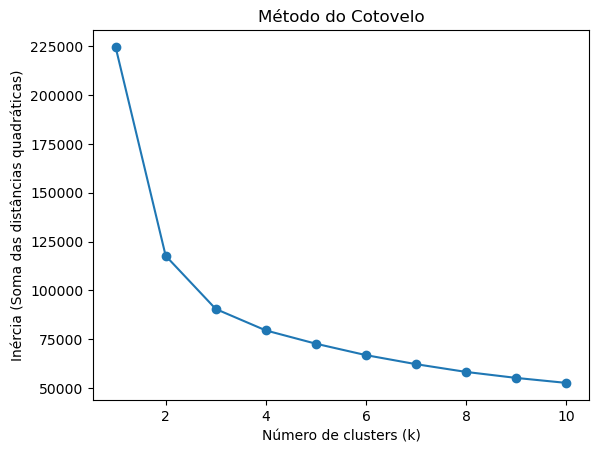

In [13]:
df_notas = df_ifnmg.copy()
notas = df_notas[["NU_NOTA_CN",	"NU_NOTA_CH",	"NU_NOTA_LC", "NU_NOTA_MT"]]

# Remover linhas com NaN nas colunas de notas
notas = notas.dropna()

# Normalizar
scaler = StandardScaler()
notas_normalizadas = scaler.fit_transform(notas)

# Testar diferentes valores de k
inercia = []
K = range(1, 11)  # de 1 a 10 clusters

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(notas_normalizadas)
    inercia.append(kmeans.inertia_)

# Plotar o gráfico do cotovelo
plt.plot(K, inercia, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia (Soma das distâncias quadráticas)")
plt.title("Método do Cotovelo")
plt.show()

O **método da silhueta** é utilizado para identificar o número ideal de clusters (k) no K-Means. Ele calcula o coeficiente de silhueta para cada ponto, que mede o quão próximo ele está de pontos do mesmo cluster em comparação com pontos de outros clusters. Valores de silhueta próximos de 1 indicam que o ponto está bem classificado e valores próximos de 0 indicam sobreposição entre clusters.

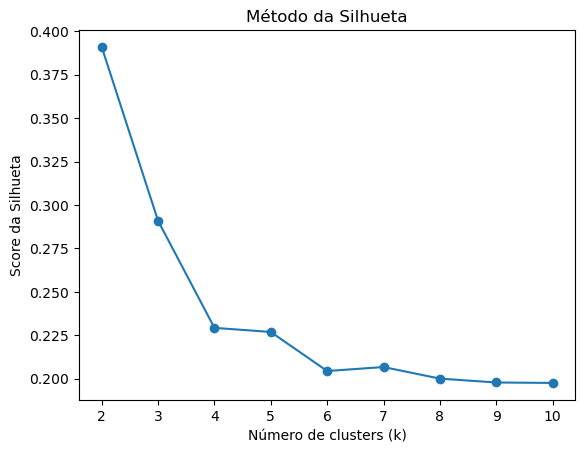

In [14]:
# Calcular os scores de silhueta para diferentes k
silhueta_scores = []
K = range(2, 11)  # começa do 2 porque silhueta não faz sentido para k=1

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(notas_normalizadas)
    score = silhouette_score(notas_normalizadas, labels)
    silhueta_scores.append(score)

# Plotar gráfico da silhueta
plt.plot(K, silhueta_scores, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Score da Silhueta")
plt.title("Método da Silhueta")
plt.show()

## **Avaliação Interna do Agrupamento e Silhueta para todos os clusters**

Para avaliar a qualidade dos agrupamentos obtidos, foram utilizadas duas métricas internas:
(a) a Soma das Distâncias Quadradas aos Centróides (SSQ), que mede a compacidade dos clusters, e
(b) a Razão entre Distância Intracluster e Intercluster (Intra/Inter), que avalia simultaneamente a coesão interna e a separação entre grupos.

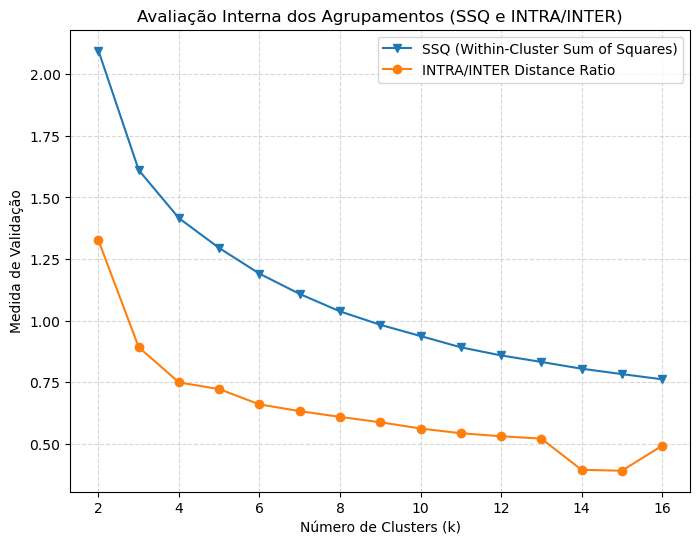

Silhueta global (k=4): 0.2293

Silhueta por cluster:
                      N     media   mediana    desvio    minimo    maximo
Cluster                                                                  
Baixo             13372  0.243356  0.257025  0.131525 -0.017131  0.460146
Levemente Abaixo  18838  0.187011  0.184366  0.104343 -0.008133  0.420511
Acima da Média    15830  0.203195  0.206955  0.116527 -0.059693  0.448704
Muito Alto         8130  0.354923  0.399155  0.147952  0.007366  0.558665


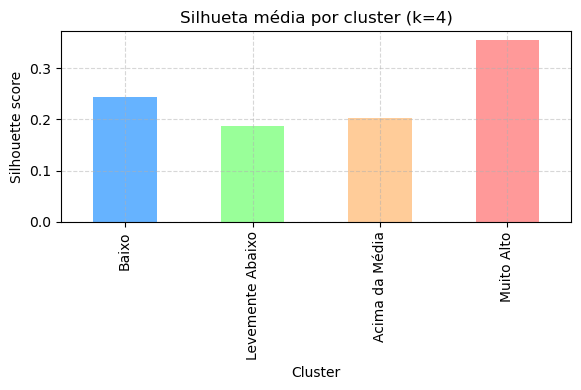

In [15]:
df_notas = df_ifnmg.copy()

colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
notas = df_notas[colunas_notas].dropna().copy()

# Normaliza apenas as notas originais
scaler = StandardScaler()
df_norm = pd.DataFrame(scaler.fit_transform(notas), columns=colunas_notas)

# ============================================================
# 2️⃣ Avaliação Interna (SSQ e INTRA/INTER)
# ============================================================
K = range(2, 17)
ssq_values = []
intra_inter_values = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_norm)
    
    ssq = kmeans.inertia_ / len(df_norm)
    ssq_values.append(ssq)
    
    intra_dists = []
    for label in np.unique(labels):
        cluster_points = df_norm[labels == label]
        if len(cluster_points) > 2:
            sample = cluster_points.sample(n=min(500, len(cluster_points)), random_state=42)
            intra = np.mean(pairwise_distances(sample))
        else:
            intra = 0
        intra_dists.append(intra)
    intra_mean = np.mean(intra_dists)
    
    centers = kmeans.cluster_centers_
    inter_mean = np.mean(pairwise_distances(centers))
    
    intra_inter_ratio = intra_mean / inter_mean
    intra_inter_values.append(intra_inter_ratio)

plt.figure(figsize=(8, 6))
plt.plot(K, ssq_values, 'v-', label='SSQ (Within-Cluster Sum of Squares)')
plt.plot(K, intra_inter_values, 'o-', label='INTRA/INTER Distance Ratio')
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Medida de Validação")
plt.title("Avaliação Interna dos Agrupamentos (SSQ e INTRA/INTER)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ============================================================
# 3️⃣ Modelo Final (k escolhido)
# ============================================================
k_final = 4  # ajuste conforme o resultado do cotovelo
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
labels = kmeans_final.fit_predict(df_norm)

# ============================================================
# 4️⃣ Análise de Silhueta
# ============================================================
sil_global = silhouette_score(df_norm, labels)
sil_samples = silhouette_samples(df_norm, labels)

centers = kmeans_final.cluster_centers_
order = centers.mean(axis=1).argsort()                
old2rank = {old:i for i, old in enumerate(order)}     
rank2name = {0:"Baixo", 1:"Levemente Abaixo", 2:"Acima da Média", 3:"Muito Alto"}

df_sil = pd.DataFrame({
    "cluster_id": labels,
    "sil": sil_samples,
})
df_sil["rank"] = df_sil["cluster_id"].map(old2rank)
df_sil["Cluster"] = df_sil["rank"].map(rank2name)

resumo = (
    df_sil
      .groupby(["rank","Cluster"])["sil"]
      .agg(N="count", media="mean", mediana="median", desvio="std", minimo="min", maximo="max")
      .reset_index()
      .sort_values("rank")
      .drop(columns="rank")
      .set_index("Cluster")
)
print(f"Silhueta global (k={k_final}): {sil_global:.4f}\n")
print("Silhueta por cluster:")
print(resumo)

plt.figure(figsize=(6,4))
(
    df_sil.groupby("Cluster")["sil"]
    .mean()
    .reindex(["Baixo","Levemente Abaixo","Acima da Média","Muito Alto"])
    .plot(kind="bar", color=["#66b3ff", "#99ff99", "#ffcc99", "#ff9999"])
)
plt.title(f"Silhueta média por cluster (k={k_final})")
plt.ylabel("Silhouette score")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## **Bisecting K-Means**

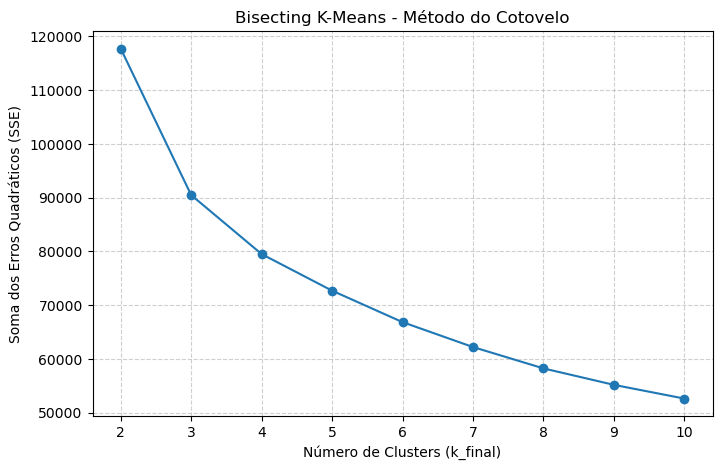

In [18]:
df_notas = df_ifnmg.copy()
colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]

notas = df_notas[colunas_notas].dropna()
scaler = StandardScaler()
X = scaler.fit_transform(notas)

def bisecting_kmeans(X, k_final=4, n_init=10, random_state=42):
    clusters = {0: X}
    labels = np.zeros(len(X), dtype=int)
    
    while len(clusters) < k_final:
        inertias = {i: KMeans(n_clusters=1, random_state=random_state).fit(X_cluster).inertia_
                    for i, X_cluster in clusters.items()}
        cluster_to_split = max(inertias, key=inertias.get)
        
        X_split = clusters[cluster_to_split]
        kmeans = KMeans(n_clusters=2, n_init=n_init, random_state=random_state)
        split_labels = kmeans.fit_predict(X_split)
        
        new_index = max(clusters.keys()) + 1
        clusters[cluster_to_split] = X_split[split_labels == 0]
        clusters[new_index] = X_split[split_labels == 1]
        
        mask = labels == cluster_to_split
        labels[mask] = np.where(split_labels == 0, cluster_to_split, new_index)
        
    return labels

resultados = []
intervalo_k = range(2, 11)  # testa de 2 a 10 clusters

for k in intervalo_k:
    labels = bisecting_kmeans(X, k_final=k)
    kmeans_final = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_final.fit(X)
    sse = kmeans_final.inertia_
    resultados.append(sse)

plt.figure(figsize=(8, 5))
plt.plot(intervalo_k, resultados, marker='o')
plt.title("Bisecting K-Means - Método do Cotovelo")
plt.xlabel("Número de Clusters (k_final)")
plt.ylabel("Soma dos Erros Quadráticos (SSE)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## **Análise dos Clusters**

Médias e desvios por cluster (padronizadas):
        NU_NOTA_CN       NU_NOTA_CH       NU_NOTA_LC       NU_NOTA_MT      
              mean   std       mean   std       mean   std       mean   std
Cluster                                                                    
0            -0.86  0.65      -1.15  0.65      -1.21  0.68      -0.82  0.58
1             1.52  0.61       1.32  0.52       1.28  0.54       1.58  0.61
2            -0.42  0.60      -0.21  0.59      -0.15  0.53      -0.43  0.61
3             0.44  0.60       0.54  0.54       0.54  0.53       0.39  0.65


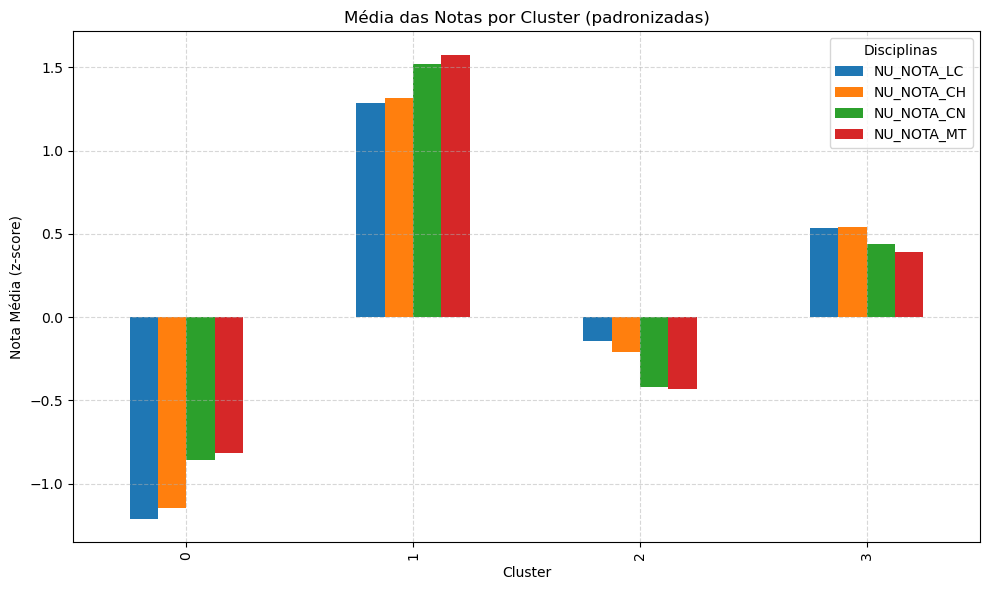

In [16]:
df_notas = df_ifnmg.copy()

colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
notas = df_notas[colunas_notas].dropna().copy()

# Normalização das notas
scaler = StandardScaler()
df_norm = pd.DataFrame(
    scaler.fit_transform(notas),
    index=notas.index,
    columns=colunas_notas
)

# ===============================
# 2️⃣ K-Means e agrupamento
# ===============================
k = 4  # escolha com base no gráfico do cotovelo
kmeans_final = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_final = kmeans_final.fit_predict(df_norm)

df_norm["Cluster"] = labels_final

# ===============================
# 3️⃣ Resumo estatístico dos clusters
# ===============================
resumo_clusters = (
    df_norm.groupby("Cluster")[colunas_notas]
    .agg(["mean", "std"])
    .round(2)
)
print("Médias e desvios por cluster (padronizadas):")
print(resumo_clusters)

# ===============================
# 4️⃣ Gráfico ordenado pelas médias das disciplinas
# ===============================
resumo_mean = df_norm.groupby("Cluster")[colunas_notas].mean()

# Ordena colunas (disciplinas) do menor para o maior valor médio
ordem_cols = resumo_mean.mean(axis=0).sort_values(ascending=True).index
resumo_sorted = resumo_mean[ordem_cols]

# Gráfico final
ax = resumo_sorted.plot(kind="bar", figsize=(10, 6))
plt.title("Média das Notas por Cluster (padronizadas)")
plt.xlabel("Cluster")
plt.ylabel("Nota Média (z-score)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Disciplinas")
plt.tight_layout()
plt.show()

## **Análise dos clusters com as notas sem normalizar**

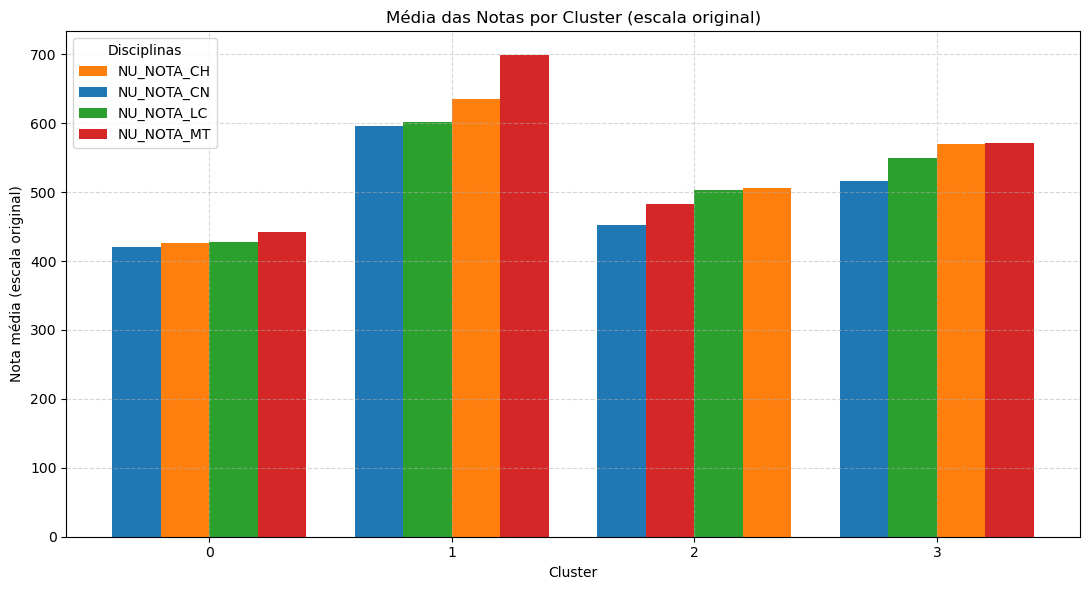

In [17]:
notas_orig = notas.copy()
notas_orig["Cluster"] = labels_final 

colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]

resumo_mean = notas_orig.groupby("Cluster")[colunas_notas].mean()

long = (
    resumo_mean.reset_index()
    .melt(id_vars="Cluster", var_name="Disciplina", value_name="Valor")
)

# ============================================
# 4️⃣ Define ranking das disciplinas dentro do cluster
# ============================================
long["Rank"] = (
    long.groupby("Cluster")["Valor"]
        .rank(method="first", ascending=True)
        .astype(int)
)

# ============================================
# 5️⃣ Cores e espaçamento
# ============================================
palette = plt.rcParams['axes.prop_cycle'].by_key()['color']
disciplinas = long["Disciplina"].unique().tolist()
cores = {d: palette[i % len(palette)] for i, d in enumerate(disciplinas)}

clusters = sorted(long["Cluster"].unique().tolist())
n_vars = long["Disciplina"].nunique()
width = 0.8 / n_vars 

centros = {c: i for i, c in enumerate(clusters)}
offsets = {r: (r - (n_vars + 1) / 2) * width for r in range(1, n_vars + 1)}

long["x"] = long["Cluster"].map(centros) + long["Rank"].map(offsets)

# ============================================
# 6️⃣ Gráfico final
# ============================================
fig, ax = plt.subplots(figsize=(11, 6))

for disc, sub in long.groupby("Disciplina"):
    ax.bar(sub["x"], sub["Valor"], width=width, label=disc, color=cores[disc])

ax.set_xticks(list(centros.values()))
ax.set_xticklabels([str(c) for c in clusters])

ax.legend(title="Disciplinas")
ax.set_title("Média das Notas por Cluster (escala original)")
ax.set_xlabel("Cluster")
ax.set_ylabel("Nota média (escala original)")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## **Cenário do desempenho dos inscritos em cada um dos anos contemplados nas bases**

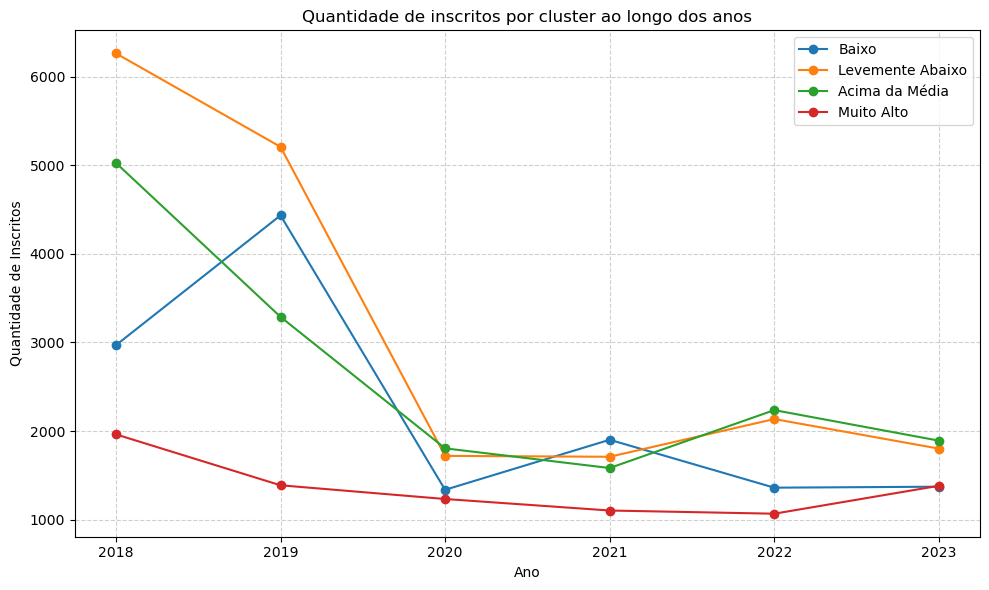

In [18]:
colunas_notas = ["NU_ANO", "NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
notas = df_ifnmg[colunas_notas].dropna().copy()

# Apenas as notas — sem criar a média
X = notas[["NU_NOTA_CN","NU_NOTA_CH","NU_NOTA_LC","NU_NOTA_MT"]].values

scaler = StandardScaler()
Xz = scaler.fit_transform(X)

kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans_final.fit_predict(Xz)

centers = kmeans_final.cluster_centers_          # centróides no espaço padronizado
centers_mean = centers.mean(axis=1)              # média de cada centróide (só para ordenar)
order = np.argsort(centers_mean)                 # do "pior" ao "melhor"

old_to_rank = {old_label: rank for rank, old_label in enumerate(order)}

rank_to_name = {
    0: "Baixo",
    1: "Levemente Abaixo",
    2: "Acima da Média",
    3: "Muito Alto"
}

notas["Cluster"] = [rank_to_name[old_to_rank[l]] for l in labels]

contagem = (
    notas.groupby(["NU_ANO", "Cluster"])
    .size()
    .reset_index(name="Quantidade")
)

# Gráfico de linhas
plt.figure(figsize=(10,6))
for nome in ["Baixo", "Levemente Abaixo", "Acima da Média", "Muito Alto"]:
    df_plot = contagem[contagem["Cluster"] == nome]
    if not df_plot.empty:
        plt.plot(df_plot["NU_ANO"], df_plot["Quantidade"], marker="o", label=nome)

plt.title("Quantidade de inscritos por cluster ao longo dos anos")
plt.xlabel("Ano")
plt.ylabel("Quantidade de Inscritos")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## **Quantidade de inscritos por grupo**

In [22]:
tabela_clusters = (notas["Cluster"]
                   .value_counts()
                   .reindex(["Baixo","Levemente Abaixo","Acima da Média","Muito Alto"])
                   .reset_index())

tabela_clusters.columns = ["Grupo", "Quantidade"]
total = int(tabela_clusters["Quantidade"].sum())
tabela_clusters["Porcentagem"] = (tabela_clusters["Quantidade"] / total * 100).round(1)

# linha total
linha_total = pd.DataFrame({
    "Grupo": ["Total"],
    "Quantidade": [total],
    "Porcentagem": [100.0]
})
tabela_final = pd.concat([tabela_clusters, linha_total], ignore_index=True)

# formatação apenas para exibir
tabela_final_fmt = tabela_final.copy()
tabela_final_fmt["Quantidade"] = tabela_final_fmt["Quantidade"].map(lambda x: f"{x:,}".replace(",", "."))
tabela_final_fmt["Porcentagem"] = tabela_final_fmt["Porcentagem"].map(lambda x: f"{x:.0f}%")

print(tabela_final_fmt)

              Grupo Quantidade Porcentagem
0             Baixo     13.372         24%
1  Levemente Abaixo     18.838         34%
2    Acima da Média     15.830         28%
3        Muito Alto      8.130         14%
4             Total     56.170        100%


## **Quantidade de inscritos por grupo entre 2018 e 2023**

In [23]:
contagem = (notas.groupby(["NU_ANO", "Cluster"])
                 .size()
                 .reset_index(name="Quantidade"))

tabela = (contagem.pivot(index="NU_ANO", columns="Cluster", values="Quantidade")
                  .reindex(columns=["Baixo","Levemente Abaixo","Acima da Média","Muito Alto"])
                  .fillna(0)
                  .astype(int)
          ).sort_index()

tabela_fmt = tabela.copy()
tabela_fmt["Total"] = tabela_fmt.sum(axis=1)

try:
    tabela_fmt = tabela_fmt.map(lambda x: f"{x:,}".replace(",", "."))
except AttributeError:
    tabela_fmt = tabela_fmt.apply(lambda col: col.map(lambda x: f"{x:,}".replace(",", ".")))

print("\nTabela formatada:")
print(tabela_fmt)


Tabela formatada:
Cluster  Baixo Levemente Abaixo Acima da Média Muito Alto   Total
NU_ANO                                                           
2018     2.969            6.265          5.028      1.962  16.224
2019     4.435            5.209          3.289      1.387  14.320
2020     1.336            1.719          1.804      1.232   6.091
2021     1.901            1.709          1.582      1.102   6.294
2022     1.360            2.135          2.236      1.066   6.797
2023     1.371            1.801          1.891      1.381   6.444


## **Média e Desvio Padrão das notas por grupo entre 2018 e 2023.**

In [19]:
cols_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
ordem_clusters = ["Baixo", "Levemente Abaixo", "Acima da Média", "Muito Alto"]

agg = (
    notas[notas["Cluster"].isin(ordem_clusters)]
      .groupby(["NU_ANO","Cluster"])[cols_notas]
      .mean()
      .round(1)
      .reset_index()
)

wide = (
    agg.pivot(index="NU_ANO", columns="Cluster", values=cols_notas)
       .reindex(columns=pd.MultiIndex.from_product([cols_notas, ordem_clusters]))
       .sort_index()
)

# Renomeia colunas com abreviações
abrevs = {
    "NU_NOTA_CN": "Ciên. Nat.",
    "NU_NOTA_CH": "Ciên. Hum.",
    "NU_NOTA_LC": "Linguagens",
    "NU_NOTA_MT": "Matemática"
}

def rotulo(col):
    disciplina, cluster = col
    return f"{abrevs[disciplina]} - {cluster}"

wide.columns = [rotulo(c) for c in wide.columns]
wide.index.name = "Ano"

tabela_fmt = wide.copy().applymap(lambda x: str(x).replace(".", ","))
print("\nMédia das notas por disciplina, ano e cluster:")
print(tabela_fmt)


Média das notas por disciplina, ano e cluster:
     Ciên. Nat. - Baixo Ciên. Nat. - Levemente Abaixo  \
Ano                                                     
2018              429,5                         450,7   
2019              408,9                         444,4   
2020              420,4                         452,1   
2021              422,7                         460,4   
2022              435,5                         459,9   
2023              416,3                         465,3   

     Ciên. Nat. - Acima da Média Ciên. Nat. - Muito Alto Ciên. Hum. - Baixo  \
Ano                                                                           
2018                       507,5                   592,8              459,0   
2019                       517,7                   589,2              414,0   
2020                       524,9                   599,3              406,2   
2021                       523,0                   603,7              421,9   
2022                 

C:\Users\fernanda.leal\AppData\Local\Temp\ipykernel_29556\3709129096.py:33: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  tabela_fmt = wide.copy().applymap(lambda x: str(x).replace(".", ","))


## **Quantidade de inscritos por grupo para cada tipo de escola**

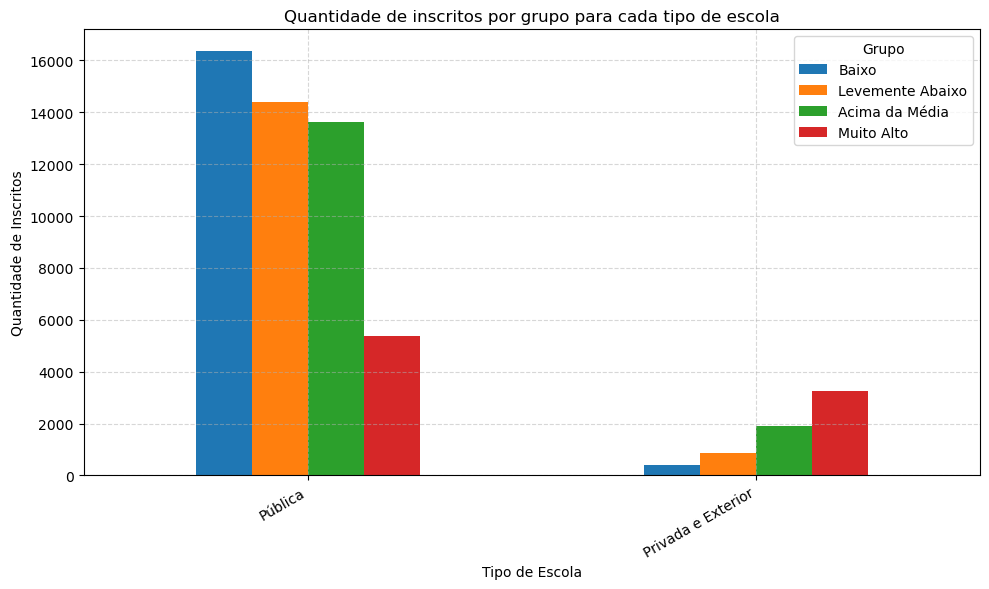

In [20]:
cols = ["TP_ESCOLA", "NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
base = df_ifnmg[cols].dropna().copy()

# Define ordem dos tipos de escola
ordem_escola = [0, 1]
base["TP_ESCOLA"] = pd.Categorical(base["TP_ESCOLA"], categories=ordem_escola, ordered=True)

# Cria base de notas
X = base[["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]].values

# Executa K-Means
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X)

# Ordena clusters com base na média dos centróides (sem usar MEDIA_GERAL)
centers = kmeans.cluster_centers_
centers_mean = centers.mean(axis=1)
ordem_por_media = np.argsort(centers_mean)

rank_map = {lab: rank for rank, lab in enumerate(ordem_por_media)}
nomes = ["Baixo", "Levemente Abaixo", "Acima da Média", "Muito Alto"]

base["Cluster"] = pd.Categorical(
    [nomes[rank_map[l]] for l in cluster_labels],
    categories=nomes, ordered=True
)

# Contagem de participantes por tipo de escola e cluster
contagem = (
    base.groupby(["TP_ESCOLA", "Cluster"], observed=True)
        .size()
        .rename("Quantidade")
        .reset_index()
)

# Cria tabela formatada
tabela = (
    contagem.pivot_table(
        index="TP_ESCOLA", columns="Cluster", values="Quantidade",
        aggfunc="sum", observed=True
    )
    .reindex(index=ordem_escola, columns=nomes)
    .fillna(0)
    .astype(int)
)

# Substitui códigos por rótulos
mapa_escola = {0: "Pública", 1: "Privada e Exterior"}
tabela.index = [mapa_escola.get(i, i) for i in tabela.index]

# Gráfico
ax = tabela.plot(kind="bar", figsize=(10, 6))
ax.set_title("Quantidade de inscritos por grupo para cada tipo de escola")
ax.set_xlabel("Tipo de Escola")
ax.set_ylabel("Quantidade de Inscritos")
ax.legend(title="Grupo")
ax.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## **Quantidade de inscritos por grupo para cada gênero**


Tabela (Sexo × Cluster) – numérica:
Cluster    Baixo  Levemente Abaixo  Acima da Média  Muito Alto  Total
Feminino    4744              6416            6718        4205  22083
Masculino   8628             12422            9112        3925  34087
Total      13372             18838           15830        8130  56170


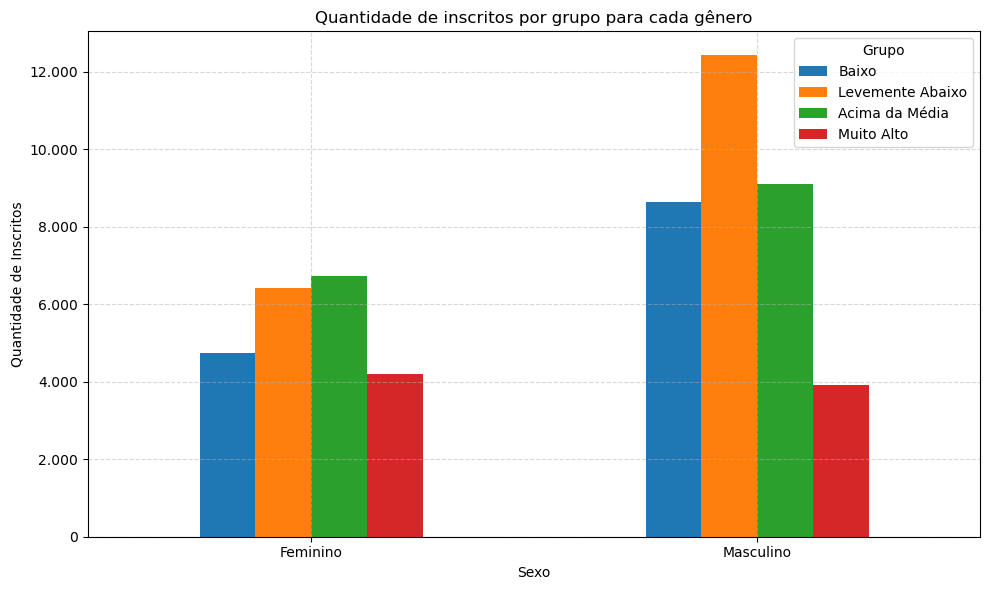

In [21]:
colunas_notas = ["TP_SEXO", "NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
notas = df_ifnmg[colunas_notas].dropna().copy()

if "Cluster" not in notas.columns:
    X = notas[["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]].values
    Xz = StandardScaler().fit_transform(X)
    
    km = KMeans(n_clusters=4, random_state=42, n_init=10).fit(Xz)
    centers = km.cluster_centers_
    order = centers.mean(axis=1).argsort()  # pior -> melhor
    old2rank = {old: r for r, old in enumerate(order)}
    rank2name = {0: "Baixo", 1: "Levemente Abaixo", 2: "Acima da Média", 3: "Muito Alto"}
    
    notas["Cluster"] = [rank2name[old2rank[l]] for l in km.labels_]

# Contagem de participantes por sexo e cluster
contagem_sexo = (
    notas.groupby(["TP_SEXO", "Cluster"], observed=True)
         .size()
         .reset_index(name="Quantidade")
)

ordem_clusters = ["Baixo", "Levemente Abaixo", "Acima da Média", "Muito Alto"]

tabela = (
    contagem_sexo.pivot_table(
        index="TP_SEXO", columns="Cluster",
        values="Quantidade", aggfunc="sum", observed=True
    )
    .reindex(columns=ordem_clusters)
    .fillna(0)
    .astype(int)
)

# Ajusta rótulos de sexo
def rotulo_sexo(v):
    return {
        0: "Feminino", 1: "Masculino",
        "0": "Feminino", "1": "Masculino",
        "F": "Feminino", "M": "Masculino"
    }.get(v, str(v))

tabela.index = [rotulo_sexo(i) for i in tabela.index]

# Adiciona totais
tabela_tot = tabela.copy()
tabela_tot["Total"] = tabela_tot.sum(axis=1)
tabela_tot.loc["Total"] = tabela_tot.sum(numeric_only=True)
print("\nTabela (Sexo × Cluster) – numérica:")
print(tabela_tot)

# Gráfico
ax = tabela.plot(kind="bar", figsize=(10, 6))
ax.set_title("Quantidade de inscritos por grupo para cada gênero")
ax.set_xlabel("Sexo")
ax.set_ylabel("Quantidade de Inscritos")
ax.legend(title="Grupo")
ax.set_xticklabels(tabela.index, rotation=0)

from matplotlib.ticker import FuncFormatter
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", ".")))

ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## **Quantidade de inscritos por grupo para cada cor/raça**


Tabela Raça × Cluster (numérica):
Cluster        Baixo  Levemente Abaixo  Acima da Média  Muito Alto  Total
Não declarado    176               242             233         162    813
Branca          2293              3788            4193        3196  13470
Preta           2032              2838            2013         655   7538
Parda           8440             11365            9042        3973  32820
Amarela          306               495             302         134   1237
Indígena         125               110              47          10    292
Total          13372             18838           15830        8130  56170


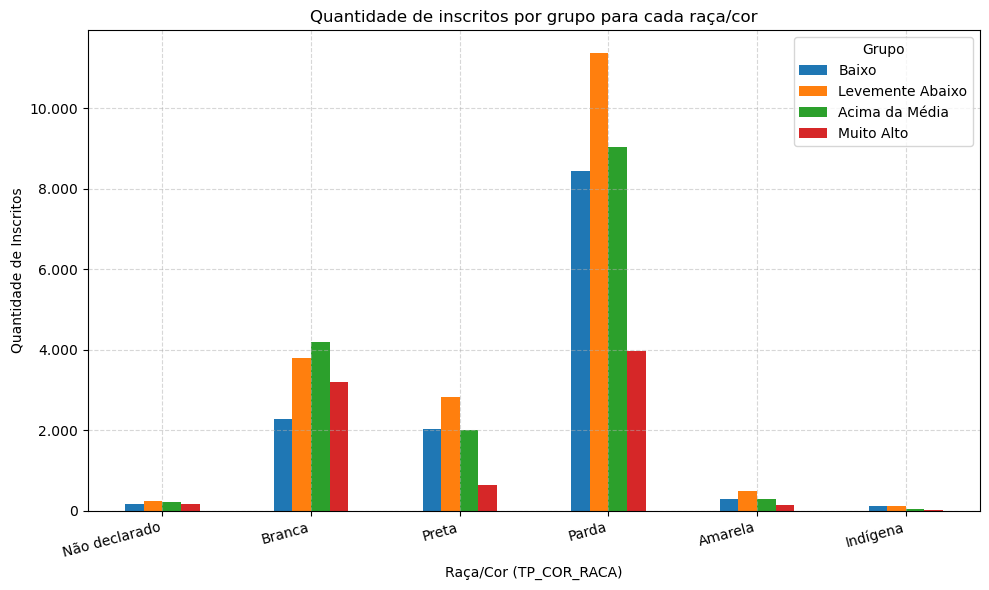

In [22]:
base = df_ifnmg.copy() if 'df_ifnmg' in globals() else df_final.copy()

# Garante que exista a coluna TP_COR_RACA
if "TP_COR_RACA" not in base.columns:
    dummy_cols = [c for c in base.columns if c.startswith("COR_RACA_")]
    if not dummy_cols:
        raise ValueError("Não encontrei TP_COR_RACA nem colunas COR_RACA_* na base.")
    base["TP_COR_RACA"] = (
        base[dummy_cols]
        .idxmax(axis=1)
        .str.replace("COR_RACA_", "", regex=False)
        .astype(int)
    )

# Seleciona apenas as notas e a variável de raça/cor
cols_notas = ["NU_NOTA_CN","NU_NOTA_CH","NU_NOTA_LC","NU_NOTA_MT"]
notas = base[["TP_COR_RACA"] + cols_notas].dropna(subset=cols_notas).copy()

if "Cluster" not in notas.columns:
    Xz = StandardScaler().fit_transform(notas[cols_notas].values)
    km = KMeans(n_clusters=4, random_state=42, n_init=10).fit(Xz)
    centers = km.cluster_centers_
    order = centers.mean(axis=1).argsort()  # pior -> melhor
    old2rank = {old: r for r, old in enumerate(order)}
    rank2name = {0:"Baixo", 1:"Levemente Abaixo", 2:"Acima da Média", 3:"Muito Alto"}
    notas["Cluster"] = [rank2name[old2rank[l]] for l in km.labels_]

# Contagem de alunos por raça e cluster
contagem_raca = (
    notas.groupby(["TP_COR_RACA","Cluster"])
         .size()
         .reset_index(name="Quantidade")
)

ordem_raca = [0,1,2,3,4,5]  # ajuste se quiser outra ordem
ordem_clusters = ["Baixo","Levemente Abaixo","Acima da Média","Muito Alto"]

tabela = (
    contagem_raca.pivot(index="TP_COR_RACA", columns="Cluster", values="Quantidade")
                 .reindex(index=[r for r in ordem_raca if r in contagem_raca["TP_COR_RACA"].unique()],
                          columns=ordem_clusters)
                 .fillna(0).astype(int)
)

# Mapeia rótulos de raça/cor
mapa_raca = {
    0: "Não declarado",
    1: "Branca",
    2: "Preta",
    3: "Parda",
    4: "Amarela",
    5: "Indígena",
}
tabela.index = [mapa_raca[i] for i in tabela.index]

# Adiciona total por linha e coluna
tabela_tot = tabela.copy()
tabela_tot["Total"] = tabela_tot.sum(axis=1)
tabela_tot.loc["Total"] = tabela_tot.sum(numeric_only=True)
print("\nTabela Raça × Cluster (numérica):")
print(tabela_tot)

# Gráfico
ax = tabela.plot(kind="bar", figsize=(10,6))
ax.set_title("Quantidade de inscritos por grupo para cada raça/cor")
ax.set_xlabel("Raça/Cor (TP_COR_RACA)")
ax.set_ylabel("Quantidade de Inscritos")
ax.set_xticklabels(tabela.index, rotation=15, ha="right")
ax.legend(title="Grupo")
from matplotlib.ticker import FuncFormatter
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", ".")))
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## **Quantidade de inscritos por grupo para cada faixa de renda mensal**


Tabela Renda × Cluster (numérica):
Cluster               Baixo  Levemente Abaixo  Acima da Média  Muito Alto  \
Nenhuma renda          1275              1169             464          65   
Até 1 salário mínimo   6042              7330            3911         781   
Entre 1 e 1,5          2983              4499            3424         942   
Entre 1,5 e 2          1123              1781            1820         777   
Entre 2 e 2,5           668              1295            1487         763   
Entre 2,5 e 3           342               715             886         571   
Entre 3 e 4             391               827            1192         903   
Entre 4 e 5             201               412             810         772   
5 ou mais               117               269             546         557   
Total                 13142             18297           14540        6131   

Cluster               Total  
Nenhuma renda          2973  
Até 1 salário mínimo  18064  
Entre 1 e 1,5         1184

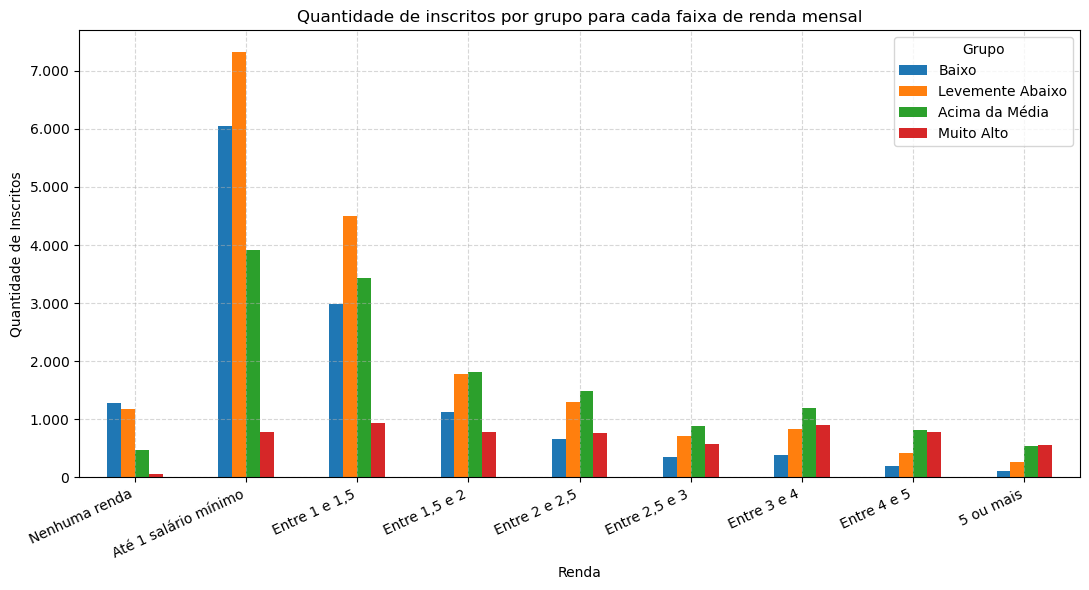

In [28]:
base = df_ifnmg.copy()

# Garante que exista a coluna RENDA_MENSAL
if "RENDA_MENSAL" not in base.columns:
    renda_dummies = [c for c in base.columns if c.startswith("RENDA_MENSAL_")]
    if not renda_dummies:
        raise ValueError("Não encontrei coluna 'RENDA_MENSAL' nem dummies 'RENDA_MENSAL_*'.")
    base["RENDA_MENSAL"] = (
        base[renda_dummies].idxmax(axis=1)
                           .str.replace("RENDA_MENSAL_", "", regex=False)
                           .astype(int)
    )

# Seleciona notas e renda
cols_notas = ["NU_NOTA_CN","NU_NOTA_CH","NU_NOTA_LC","NU_NOTA_MT"]
notas = base[["RENDA_MENSAL"] + cols_notas].dropna(subset=cols_notas).copy()

# Cria clusters apenas com base nas notas
if "Cluster" not in notas.columns:
    Xz = StandardScaler().fit_transform(notas[cols_notas].values)
    km = KMeans(n_clusters=4, random_state=42, n_init=10).fit(Xz)
    centers = km.cluster_centers_
    ordem = centers.mean(axis=1).argsort()  # pior -> melhor
    old2rank = {old: r for r, old in enumerate(ordem)}
    rank2name = {0:"Baixo", 1:"Levemente Abaixo", 2:"Acima da Média", 3:"Muito Alto"}
    notas["Cluster"] = [rank2name[old2rank[l]] for l in km.labels_]

# Agrupa por renda e cluster
contagem_renda = (
    notas.dropna(subset=["RENDA_MENSAL"])
         .groupby(["RENDA_MENSAL","Cluster"])
         .size()
         .reset_index(name="Quantidade")
)

# Define a ordem e os rótulos das faixas de renda
ordem_renda = [0,1,2,3,4,5,6,7,8]
mapa_renda = {
    0: "Nenhuma renda",
    1: "Até 1 salário mínimo",
    2: "Entre 1 e 1,5",
    3: "Entre 1,5 e 2",
    4: "Entre 2 e 2,5",
    5: "Entre 2,5 e 3",
    6: "Entre 3 e 4",
    7: "Entre 4 e 5",
    8: "5 ou mais"
}

ordem_clusters = ["Baixo","Levemente Abaixo","Acima da Média","Muito Alto"]

idx_validos = [r for r in ordem_renda if r in contagem_renda["RENDA_MENSAL"].unique()]
tabela = (
    contagem_renda.pivot(index="RENDA_MENSAL", columns="Cluster", values="Quantidade")
                  .reindex(index=idx_validos, columns=ordem_clusters)
                  .fillna(0).astype(int)
)
tabela.index = [mapa_renda[i] for i in tabela.index]

# Tabela total
tabela_tot = tabela.copy()
tabela_tot["Total"] = tabela_tot.sum(axis=1)
tabela_tot.loc["Total"] = tabela_tot.sum(numeric_only=True)
print("\nTabela Renda × Cluster (numérica):")
print(tabela_tot)

# Gráfico
ax = tabela.plot(kind="bar", figsize=(11,6))
ax.set_title("Quantidade de inscritos por grupo para cada faixa de renda mensal")
ax.set_xlabel("Renda")
ax.set_ylabel("Quantidade de Inscritos")
ax.set_xticklabels(tabela.index, rotation=25, ha="right")
ax.legend(title="Grupo")

from matplotlib.ticker import FuncFormatter
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", ".")))

ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## **TESTE**

Índice Rand Ajustado (ARI) entre K-Means e Birch: 0.311


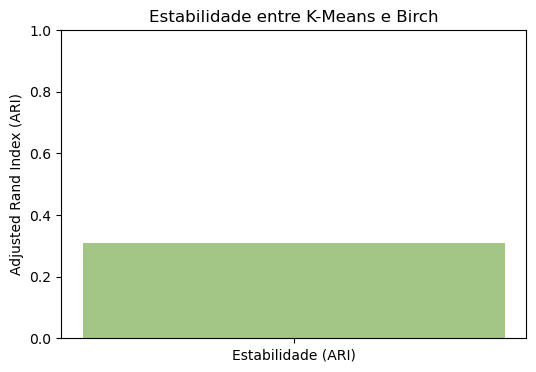

In [23]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, Birch
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt

# ====== Pré-processamento ======
df_notas = df_ifnmg.copy()

colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
notas = df_notas[colunas_notas].dropna()
notas["MEDIA_GERAL"] = notas.mean(axis=1)

scaler = StandardScaler()
df_norm = pd.DataFrame(scaler.fit_transform(notas), columns=notas.columns)

# ====== Número de clusters ======
k = 4

# ====== Modelo 1: K-Means ======
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(df_norm)

# ====== Modelo 2: Birch ======
birch = Birch(n_clusters=k)
labels_birch = birch.fit_predict(df_norm)

# ====== Métrica de estabilidade ======
ari = adjusted_rand_score(labels_kmeans, labels_birch)
print(f"Índice Rand Ajustado (ARI) entre K-Means e Birch: {ari:.3f}")

# ====== Visualização ======
plt.figure(figsize=(6, 4))
plt.bar(["Estabilidade (ARI)"], [ari], color="#a3c585")
plt.ylim(0, 1)
plt.title("Estabilidade entre K-Means e Birch")
plt.ylabel("Adjusted Rand Index (ARI)")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt

# ====== Pré-processamento ======
df_notas = df_ifnmg.copy()

colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
notas = df_notas[colunas_notas].dropna()
notas["MEDIA_GERAL"] = notas.mean(axis=1)

scaler = StandardScaler()
df_norm = pd.DataFrame(scaler.fit_transform(notas), columns=notas.columns)

# ====== Número de clusters ======
k = 4

# ====== Modelo 1: K-Means tradicional ======
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(df_norm)

# ====== Modelo 2: MiniBatch K-Means ======
mini_kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1000, n_init=10)
labels_mini = mini_kmeans.fit_predict(df_norm)

# ====== Métrica de estabilidade ======
ari = adjusted_rand_score(labels_kmeans, labels_mini)
print(f"Índice Rand Ajustado (ARI) entre K-Means e MiniBatch K-Means: {ari:.3f}")

# ====== Visualização ======
plt.figure(figsize=(6, 4))
plt.bar(["Estabilidade (ARI)"], [ari], color="#6fa8dc")
plt.ylim(0, 1)
plt.title("Estabilidade entre K-Means e MiniBatch K-Means")
plt.ylabel("Adjusted Rand Index (ARI)")
plt.show()
